In [2]:
import pandas as pd

te = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/data/translationEfficiency/1h_TE.csv', index_col=0)
te

,RPFs.DC1_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFs.DC2_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFs.DC3_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC1_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC2_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC3_184t_bw_star_Aligned.sortedByCoord.out.bam,mRNA.DC4_184t_star_Aligned.sortedByCoord.out.bam,mRNA.DC5_184t_star_Aligned.sortedByCoord.out.bam,mRNA.DC6_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC4_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC5_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC6_184t_star_Aligned.sortedByCoord.out.bam,TE.DC1_184t_bw_star_Aligned.sortedByCoord.out.bam,TE.DC2_184t_bw_star_Aligned.sortedByCoord.out.bam,TE.DC3_184t_bw_star_Aligned.sortedByCoord.out.bam
FBgn0000008,38.770331,55.221932,31.672519,20,30,15,167.532252,169.662158,158.137996,617,637,570,0.235981,0.329434,0.205309
FBgn0000017,452.750305,425.247500,349.575924,553,547,392,268.344824,255.462285,243.249989,2340,2271,2076,1.684645,1.662028,1.435316
FBgn0000018,76.051657,122.210588,152.932010,13,22,24,238.452601,202.554505,246.989906,291,252,295,0.321783,0.605295,0.620719
FBgn0000024,1.238656,0.000000,0.000000,1,0,0,0.346996,0.000000,0.000000,2,0,0,1.661962,1.000000,1.000000
FBgn0000032,331.861777,497.301142,485.732919,64,101,86,753.181704,636.928696,760.664213,1037,894,1025,0.441355,0.781124,0.639039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FBgn0266708,0.000000,0.000000,23.125424,0,0,3,0.000000,0.000000,0.000000,0,0,0,1.000000,1.000000,24.125424
FBgn0267366,0.000000,0.000000,10.420846,0,0,1,0.000000,0.000000,0.000000,0,0,0,1.000000,1.000000,11.420846
FBgn0283479,0.000000,0.000000,12.659654,0,0,2,0.813980,1.596894,0.000000,1,2,0,0.551274,0.385075,13.659654
FBgn0286833,0.000000,0.000000,45.006566,0,0,3,3.858394,1.892382,3.942345,2,1,2,0.205829,0.345736,9.308651


In [17]:
teAvg = te.iloc[:, -3:].mean(axis=1)
myTeAvg = (te.iloc[:, :3].mean(axis=1)+1) / (te.iloc[:, 6:9].mean(axis=1)+1)
myTeAvg_nopseudo = (te.iloc[:, :3].mean(axis=1)) / (te.iloc[:, 6:9].mean(axis=1))

# bind the three averages together
teAvgAll = pd.concat([teAvg, myTeAvg, myTeAvg_nopseudo], axis=1)
teAvgAll.columns = ['teAvg', 'myTeAvg', 'myTeAvg_nopseudo']
teAvgAll

,teAvg,myTeAvg,myTeAvg_nopseudo
FBgn0000008,0.256908,0.258191,0.253698
FBgn0000017,1.593996,1.598029,1.600368
FBgn0000018,0.515932,0.512584,0.510459
FBgn0000024,1.220654,1.266406,3.569655
FBgn0000032,0.620506,0.611901,0.611359
...,...,...,...
FBgn0266708,8.708475,8.708475,inf
FBgn0267366,4.473615,4.473615,inf
FBgn0283479,4.865335,2.894108,5.251064
FBgn0286833,3.286739,3.782093,4.643145


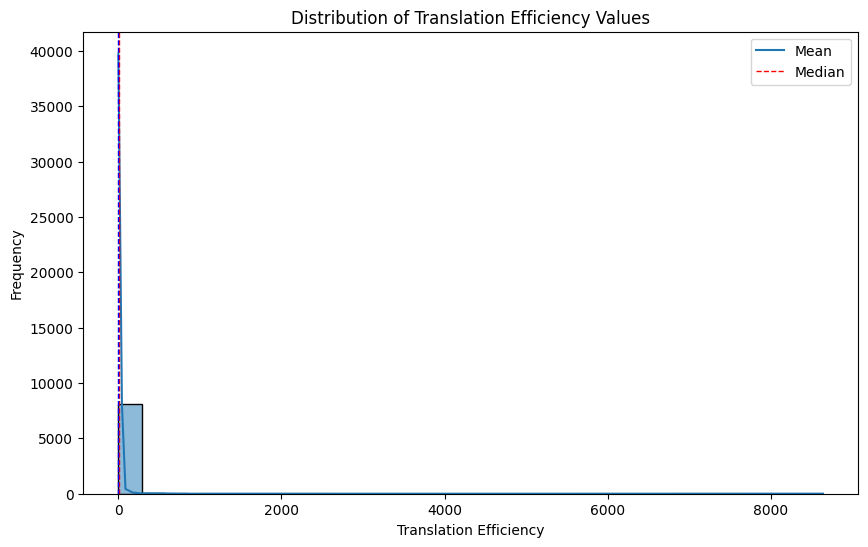

In [3]:

#plot the distribution of the TE values
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(teAvg, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg.mean(), 'Median': teAvg.median()})
plt.show()

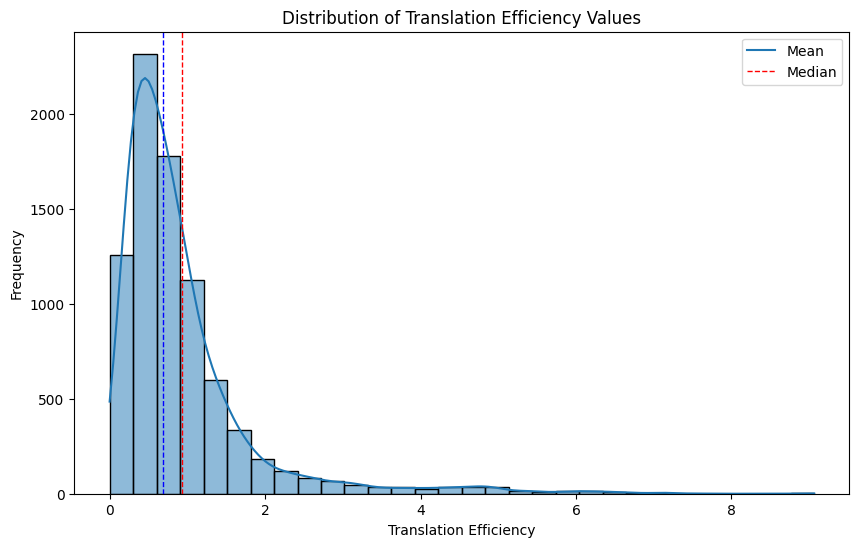

In [4]:
#plot the distribution of the TE values
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.figure(figsize=(10, 6))
sns.histplot(np.log(teAvg+1), bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(np.log(teAvg+1).mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(np.log(teAvg+1).median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': np.log(teAvg+1).mean(), 'Median': np.log(teAvg+1).median()})
plt.show()

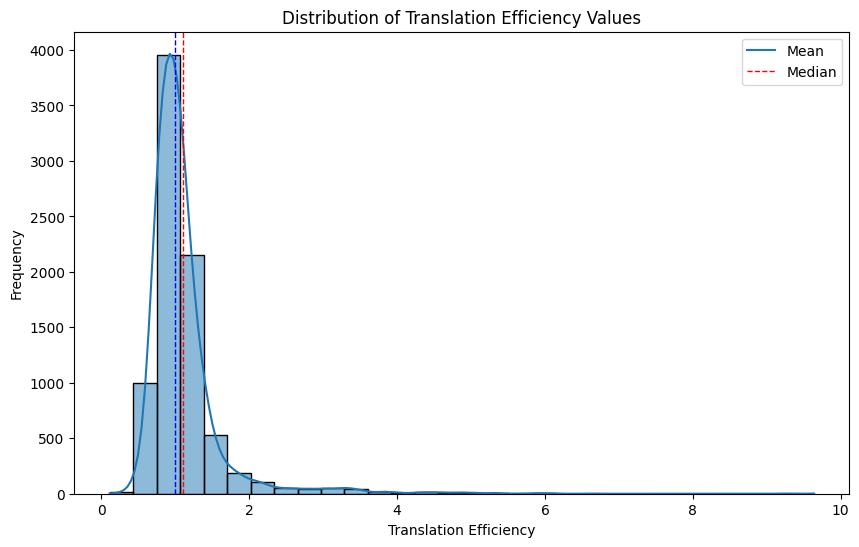

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

teAvg_tmp = teAvg**(1/4)
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

7814
371


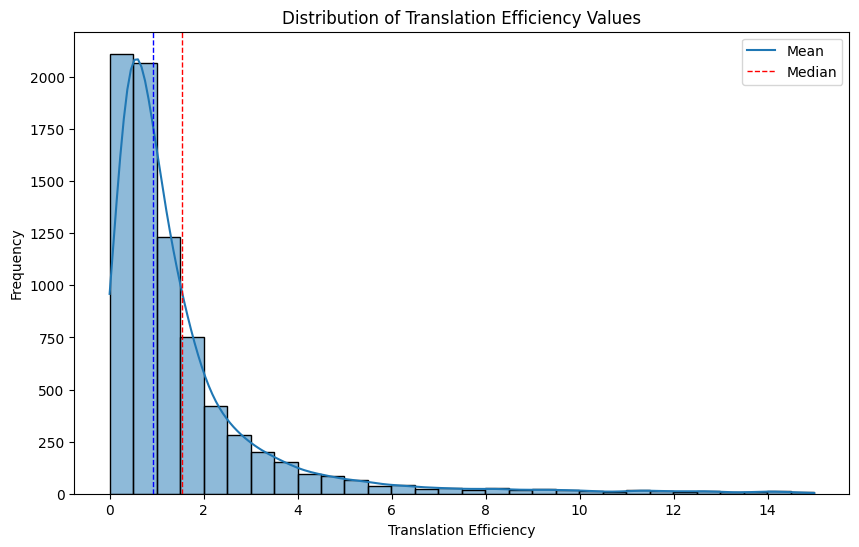

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(len(teAvg[teAvg < 15]))
print(len(teAvg)-len(teAvg[teAvg < 15]))
teAvg_tmp = teAvg[teAvg < 15]
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

In [13]:
print(len(teAvg[teAvg < 20]))
print(len(teAvg)-len(teAvg[teAvg < 20]))

7870
315


371
7814


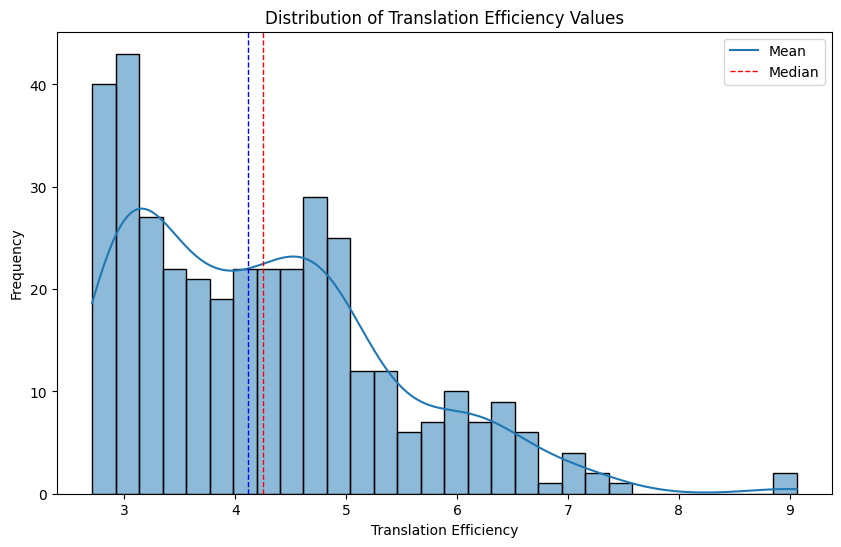

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

threshold = 15
print(len(teAvg[teAvg > threshold]))
print(len(teAvg)-len(teAvg[teAvg > threshold]))
teAvg_tmp = np.log(teAvg[teAvg > threshold])
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

In [12]:
max(teAvg)

8640.558882970803

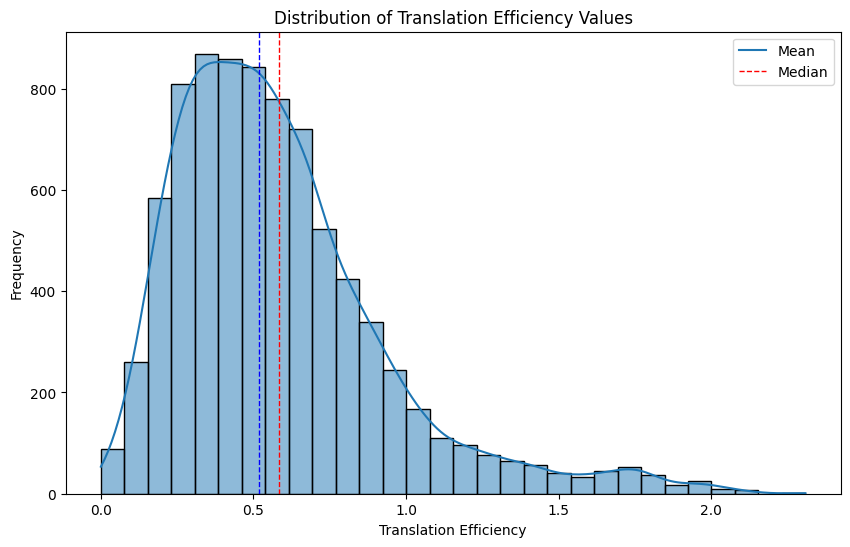

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

teAvg_tmp = np.log(1+np.log(teAvg+1))
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

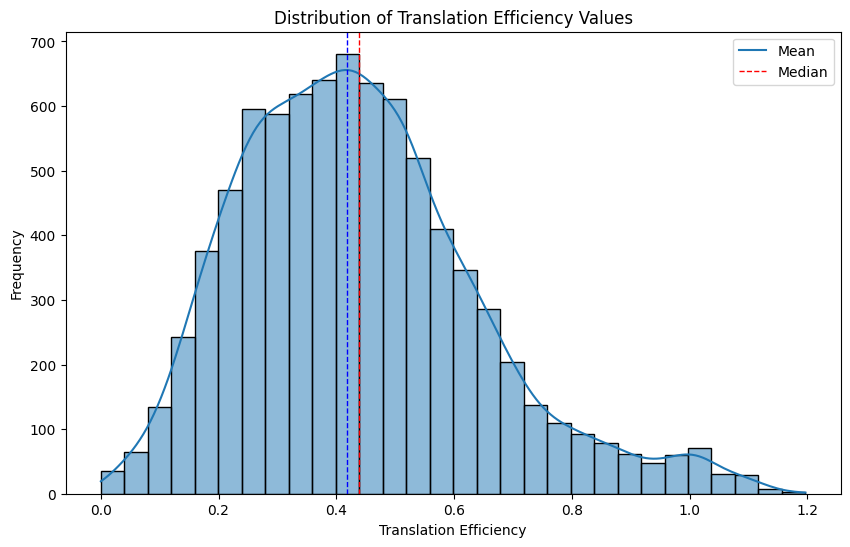

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

teAvg_tmp = np.log(1+np.log(1+np.log(teAvg+1)))
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

In [18]:
filt1 = (te["RPFsRawCounts.DC1_184t_bw_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["RPFsRawCounts.DC2_184t_bw_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["RPFsRawCounts.DC3_184t_bw_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["mRNARawCounts.DC4_184t_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["mRNARawCounts.DC5_184t_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["mRNARawCounts.DC6_184t_star_Aligned.sortedByCoord.out.bam"].values > 0 )
filt2 = (te["RPFsRawCounts.DC1_184t_bw_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["RPFsRawCounts.DC2_184t_bw_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["RPFsRawCounts.DC3_184t_bw_star_Aligned.sortedByCoord.out.bam"].values > 0)
filt3 = (te["mRNARawCounts.DC4_184t_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["mRNARawCounts.DC5_184t_star_Aligned.sortedByCoord.out.bam"].values > 0) * (te["mRNARawCounts.DC6_184t_star_Aligned.sortedByCoord.out.bam"].values > 0) 

print(len(filt1))
print(len(filt1)-filt1.sum(),filt1.sum()) #at least one RPF and mRNA read in each replicate
print(len(filt1)-filt2.sum(),filt2.sum()) #at least one RPF read in each replicate
print(len(filt1)-filt3.sum(),filt3.sum()) #at least one mRNA read in each replicate
print((len(filt1)-filt3.sum())-((len(filt1)-filt1.sum())-(len(filt1)-filt2.sum()))) #overlapping samples from both groups

8185
1741 6444
1404 6781
1026 7159
689


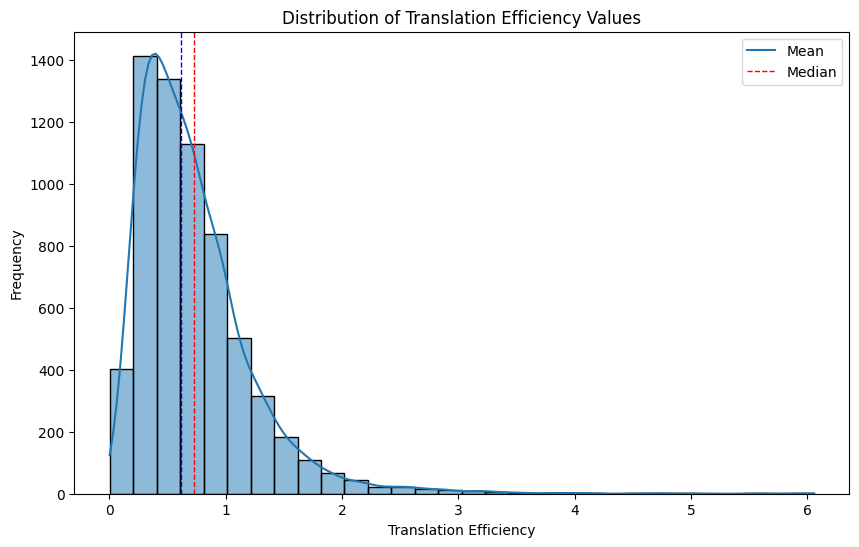

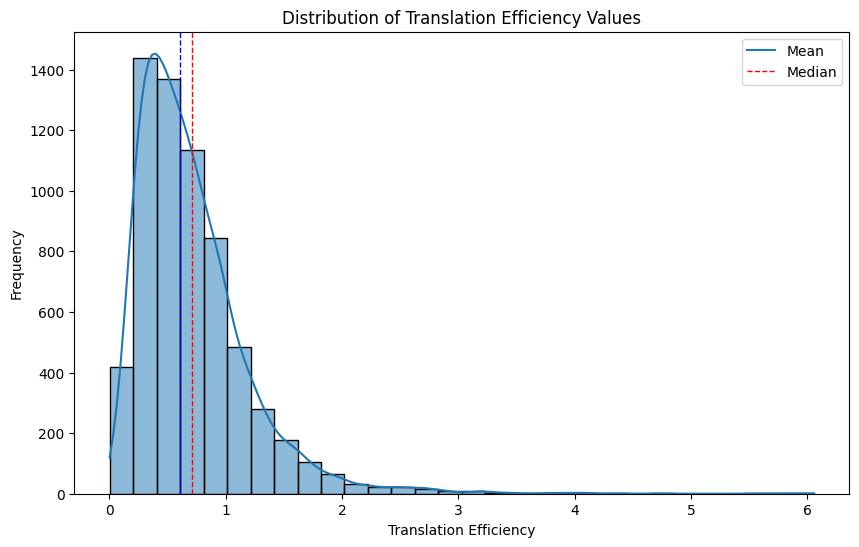

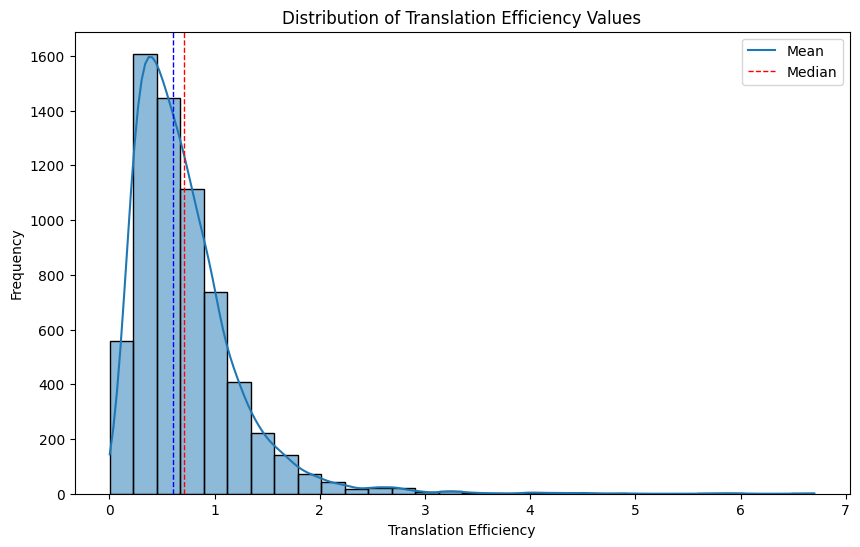

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

teAvg_tmp = np.log(1+teAvg[filt1])
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

teAvg_tmp = np.log(1+myTeAvg[filt1])
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

teAvg_tmp = np.log(1+myTeAvg_nopseudo[filt1])
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

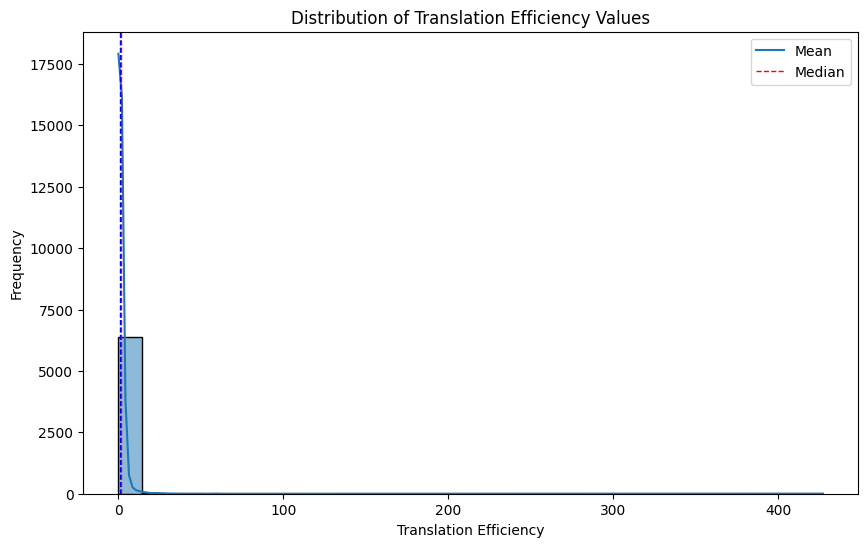

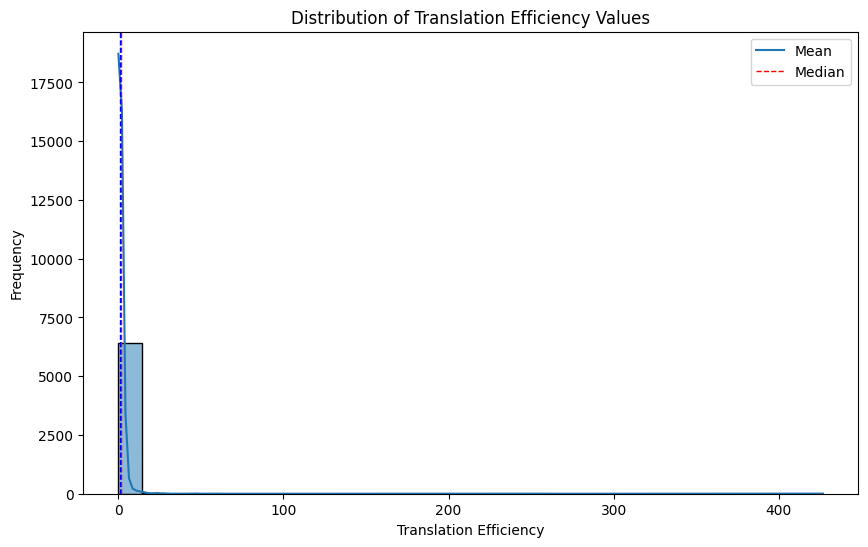

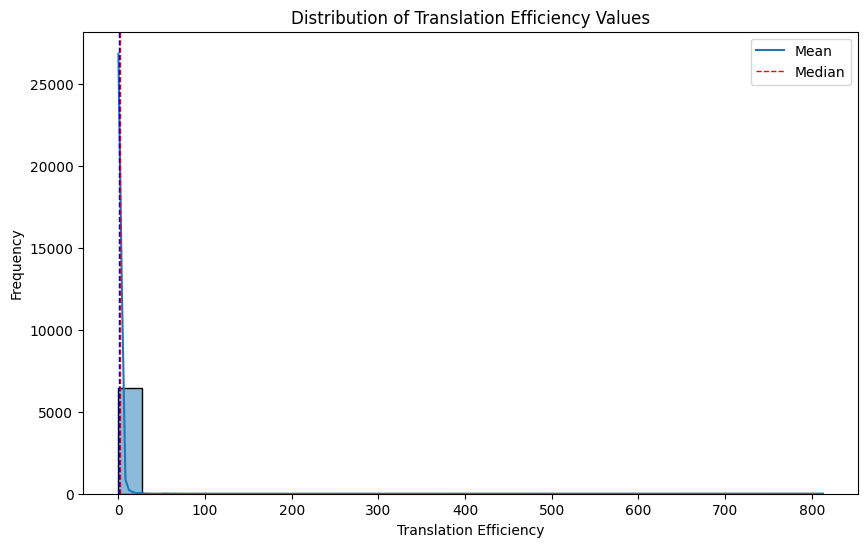

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

teAvg_tmp = teAvg[filt1]
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

teAvg_tmp = myTeAvg[filt1]
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

teAvg_tmp = myTeAvg_nopseudo[filt1]
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

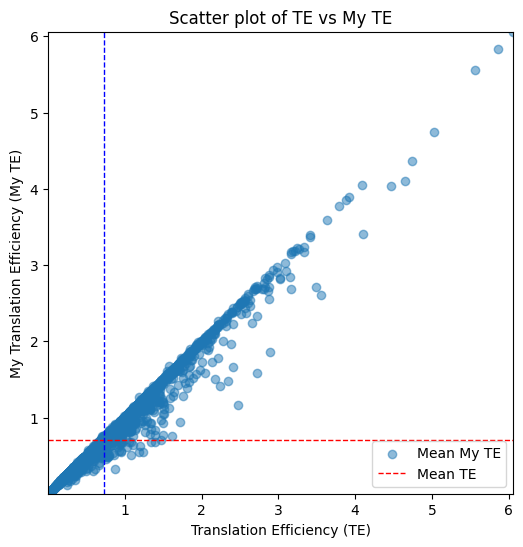

In [24]:
# scatter plot of teAvg vs myTeAvg
plt.figure(figsize=(6, 6))

x_data = np.log(1+teAvg[filt1])
y_data = np.log(1+myTeAvg[filt1])

plt.scatter(x_data, y_data, alpha=0.5)
plt.title('Scatter plot of TE vs My TE')
plt.xlabel('Translation Efficiency (TE)')
plt.ylabel('My Translation Efficiency (My TE)')

# Determine common range for x and y axes
min_val = min(x_data.min(), y_data.min())
max_val = max(x_data.max(), y_data.max())
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Plotting mean lines - note that the means should be calculated on the transformed data if you want them to align with the plot scale
plt.axhline(y_data.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(x_data.mean(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean My TE': y_data.mean(), 'Mean TE': x_data.mean()})
plt.show()

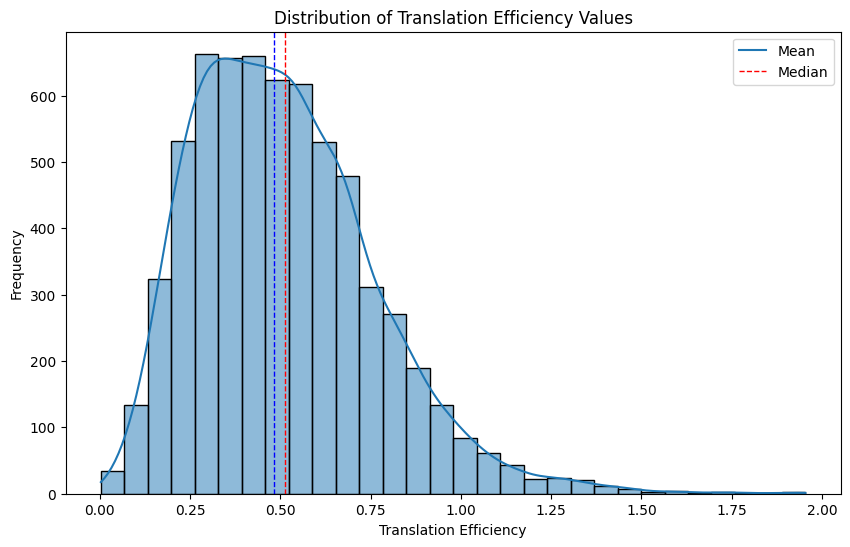

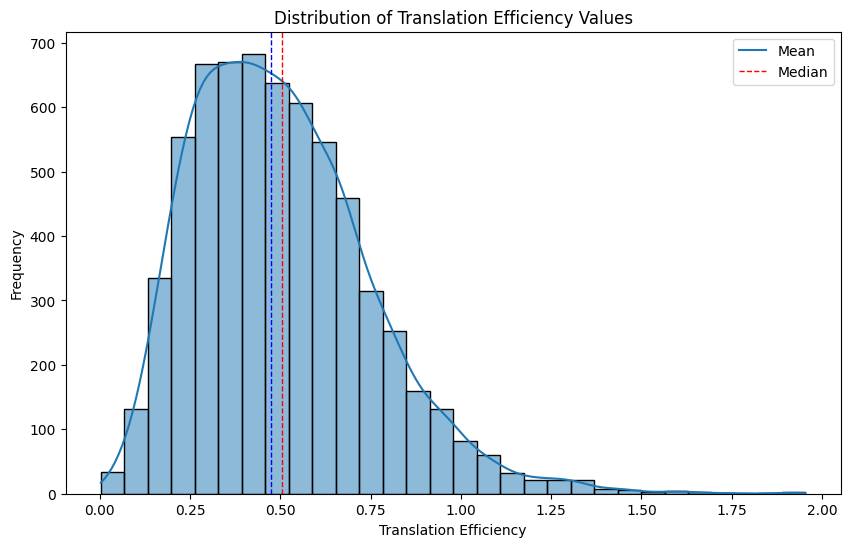

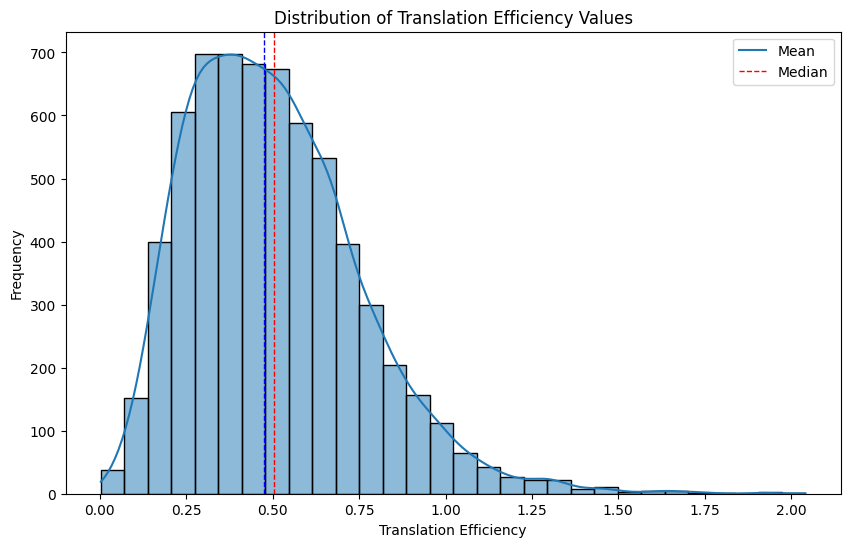

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

teAvg_tmp = np.log(1+np.log(1+teAvg[filt1]))
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

teAvg_tmp = np.log(1+np.log(1+myTeAvg[filt1]))
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

teAvg_tmp = np.log(1+np.log(1+myTeAvg_nopseudo[filt1]))
plt.figure(figsize=(10, 6))
sns.histplot(teAvg_tmp, bins=30, kde=True)
plt.title('Distribution of Translation Efficiency Values')
plt.xlabel('Translation Efficiency')
plt.ylabel('Frequency')
plt.axvline(teAvg_tmp.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(teAvg_tmp.median(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean': teAvg_tmp.mean(), 'Median': teAvg_tmp.median()})
plt.show()

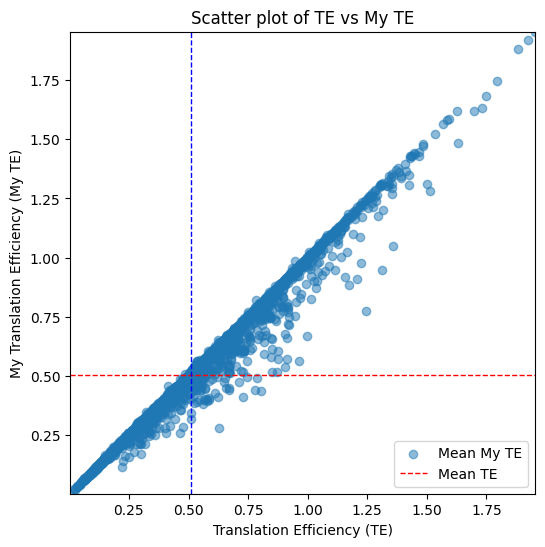

In [26]:
# scatter plot of teAvg vs myTeAvg
plt.figure(figsize=(6, 6))

x_data = np.log(1+np.log(1+teAvg[filt1]))
y_data = np.log(1+np.log(1+myTeAvg[filt1]))

plt.scatter(x_data, y_data, alpha=0.5)
plt.title('Scatter plot of TE vs My TE')
plt.xlabel('Translation Efficiency (TE)')
plt.ylabel('My Translation Efficiency (My TE)')

# Determine common range for x and y axes
min_val = min(x_data.min(), y_data.min())
max_val = max(x_data.max(), y_data.max())
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Plotting mean lines - note that the means should be calculated on the transformed data if you want them to align with the plot scale
plt.axhline(y_data.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(x_data.mean(), color='blue', linestyle='dashed', linewidth=1)
plt.legend({'Mean My TE': y_data.mean(), 'Mean TE': x_data.mean()})
plt.show()